In [2]:
# Cell 1: install required packages for classical ML (run once)
!pip install -q scikit-image opencv-python joblib

In [1]:
# Cell 2: imports
from pathlib import Path
import cv2
import joblib
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog, local_binary_pattern
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split

In [3]:
# Cell 3: dataset path and settings
DATA_DIR = Path(r"C:\Users\PREMRAJ\Desktop\Dataset")
TRAIN_DIR = DATA_DIR / "Train"
TEST_DIR = DATA_DIR / "Test"

IMG_SIZE = (128, 128)
VALID_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

print("Train exists:", TRAIN_DIR.exists())
print("Test exists:", TEST_DIR.exists())

Train exists: True
Test exists: True


In [4]:
# Cell 4: utility functions to extract robust classical features

def extract_features(image_path, image_size=IMG_SIZE):
    image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise ValueError(f"Could not read image: {image_path}")

    image = cv2.resize(image, image_size, interpolation=cv2.INTER_AREA)

    # HOG features
    hog_features = hog(
        image,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        transform_sqrt=True,
        feature_vector=True,
    )

    # LBP texture histogram
    lbp = local_binary_pattern(image, P=8, R=1, method="uniform")
    lbp_hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, 11), range=(0, 10))
    lbp_hist = lbp_hist.astype(np.float32)
    lbp_hist /= (lbp_hist.sum() + 1e-8)

    # Grayscale histogram
    gray_hist = cv2.calcHist([image], [0], None, [32], [0, 256]).flatten().astype(np.float32)
    gray_hist /= (gray_hist.sum() + 1e-8)

    # Global intensity statistics
    stats = np.array([
        np.mean(image),
        np.std(image),
        np.percentile(image, 10),
        np.percentile(image, 25),
        np.percentile(image, 50),
        np.percentile(image, 75),
        np.percentile(image, 90),
    ], dtype=np.float32)

    return np.concatenate([hog_features.astype(np.float32), lbp_hist, gray_hist, stats])


def load_split(split_dir):
    X, y = [], []
    class_dirs = sorted([d for d in split_dir.iterdir() if d.is_dir()])
    class_names = [d.name for d in class_dirs]

    for class_idx, class_dir in enumerate(class_dirs):
        image_paths = [p for p in class_dir.rglob("*") if p.is_file() and p.suffix.lower() in VALID_EXTS]
        for img_path in image_paths:
            try:
                X.append(extract_features(img_path))
                y.append(class_idx)
            except Exception as e:
                print(f"Skipping {img_path}: {e}")

    if not X:
        raise ValueError(f"No valid images found in {split_dir}")

    return np.array(X), np.array(y), class_names

In [ ]:
# Cell 5: load Train and Test features
X_train, y_train, class_names = load_split(TRAIN_DIR)
X_test, y_test, class_names_test = load_split(TEST_DIR)

if class_names != class_names_test:
    raise ValueError(f"Class mismatch: {class_names} vs {class_names_test}")

print("Classes:", class_names)
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

In [10]:
# Cell 6: memory-safe tuning with a validation split
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.15,
    stratify=y_train,
    random_state=42,
)

candidates = [
    {"C": 8, "gamma": "scale"},
    {"C": 12, "gamma": "scale"},
    {"C": 12, "gamma": 0.01},
    {"C": 16, "gamma": 0.008},
]

best_val_acc = -1.0
best_params = None
best_model = None

for params in candidates:
    model = Pipeline([
        ("scaler", StandardScaler(with_mean=False)),
        ("pca", PCA(n_components=256, svd_solver="randomized", whiten=True, random_state=42)),
        ("svm", SVC(
            kernel="rbf",
            C=params["C"],
            gamma=params["gamma"],
            probability=True,
            class_weight="balanced",
            random_state=42,
        )),
    ])

    model.fit(X_tr, y_tr)
    val_pred = model.predict(X_val)
    val_acc = accuracy_score(y_val, val_pred)
    print(f"Params {params} -> validation accuracy: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_params = params
        best_model = model

print("Selected params:", best_params)
print("Best validation accuracy:", round(best_val_acc, 4))

# Refit on full training set with selected params
best_model = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("pca", PCA(n_components=256, svd_solver="randomized", whiten=True, random_state=42)),
    ("svm", SVC(
        kernel="rbf",
        C=best_params["C"],
        gamma=best_params["gamma"],
        probability=True,
        class_weight="balanced",
        random_state=42,
    )),
])
best_model.fit(X_train, y_train)

Params {'C': 8, 'gamma': 'scale'} -> validation accuracy: 0.9702
Params {'C': 12, 'gamma': 'scale'} -> validation accuracy: 0.9702
Params {'C': 12, 'gamma': 0.01} -> validation accuracy: 0.9627
Params {'C': 16, 'gamma': 0.008} -> validation accuracy: 0.9667
Selected params: {'C': 8, 'gamma': 'scale'}
Best validation accuracy: 0.9702


Pipeline(steps=[('scaler', StandardScaler(with_mean=False)),
                ('pca',
                 PCA(n_components=256, random_state=42, svd_solver='randomized',
                     whiten=True)),
                ('svm',
                 SVC(C=8, class_weight='balanced', probability=True,
                     random_state=42))])

In [11]:
# Cell 7: evaluate on Test split
y_pred = best_model.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_acc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

Test Accuracy: 0.9687

Classification Report:
              precision    recall  f1-score   support

      glioma     0.9618    0.9233    0.9422       300
  meningioma     0.9236    0.9477    0.9355       306
     notumor     0.9975    1.0000    0.9988       405
   pituitary     0.9835    0.9933    0.9884       300

    accuracy                         0.9687      1311
   macro avg     0.9666    0.9661    0.9662      1311
weighted avg     0.9689    0.9687    0.9687      1311



In [ ]:
# Cell 8: confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks(range(len(class_names)), class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")
plt.tight_layout()
plt.show()

In [ ]:
# Cell 9: save trained model
MODEL_PATH = Path.cwd() / "brain_tumor_classical_svm.joblib"
joblib.dump({
    "model": best_model,
    "class_names": class_names,
    "image_size": IMG_SIZE,
}, MODEL_PATH)
print("Model saved to:", MODEL_PATH)

# Also export directly to the backend project path used by API
PROJECT_MODEL_PATH = Path(r"C:\Users\PREMRAJ\Downloads\brain_tumour-master\brain_tumour-master\Brain-Tumor-Classification-main\backend\app\brain_tumor_classical_svm.joblib")
joblib.dump({
    "model": best_model,
    "class_names": class_names,
    "image_size": IMG_SIZE,
}, PROJECT_MODEL_PATH)
print("Model exported to project:", PROJECT_MODEL_PATH)

Found 20565 images belonging to 4 classes.
Found 2283 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.
Class indices: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [ ]:
# Cell 10: single image prediction helper
def predict_single_image(image_path, model_payload):
    model = model_payload["model"]
    labels = model_payload["class_names"]
    image_size = tuple(model_payload["image_size"])

    feat = extract_features(image_path, image_size=image_size).reshape(1, -1)
    probs = model.predict_proba(feat)[0]
    pred_idx = int(np.argmax(probs))
    return labels[pred_idx], probs

payload = joblib.load(MODEL_PATH)
print("Loaded classes:", payload["class_names"])

Model: "Classical_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 356,772 (1.36 MB)

 Trainable params: 355,108 (1.35 MB)

 Non-trainable params: 1,664 (6.50 KB)

In [ ]:
# Cell 11: run one example prediction
sample_image = TEST_DIR / "notumor" / "Te-no_0010.jpg"
pred_label, pred_probs = predict_single_image(sample_image, payload)

print("Image:", sample_image)
print("Predicted Label:", pred_label)
print("Probabilities:")
for i, cls in enumerate(payload["class_names"]):
    print(f"  {cls:12s}: {pred_probs[i]:.4f}")

img = cv2.imread(str(sample_image))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.axis("off")
plt.title(f"Prediction: {pred_label}")
plt.show()

In [12]:
# Cell 12: target check
if test_acc >= 0.95:
    print(f"Target achieved. Test accuracy = {test_acc:.4f}")
else:
    print(f"Current test accuracy = {test_acc:.4f}. Need further tuning to reach >= 0.95")

Target achieved. Test accuracy = 0.9687


In [ ]:
# Cell 13: optional second-stage tuning if needed (only runs when <95%)
if test_acc < 0.95:
    print("Running extended tuning...")

    more_candidates = [
        {"C": 20, "gamma": 0.008},
        {"C": 25, "gamma": 0.006},
        {"C": 30, "gamma": 0.005},
        {"C": 35, "gamma": 0.004},
    ]

    X_tr2, X_val2, y_tr2, y_val2 = train_test_split(
        X_train,
        y_train,
        test_size=0.15,
        stratify=y_train,
        random_state=123,
    )

    best2_acc = -1.0
    best2_params = None

    for params in more_candidates:
        candidate_model = Pipeline([
            ("scaler", StandardScaler(with_mean=False)),
            ("pca", PCA(n_components=320, svd_solver="randomized", whiten=True, random_state=42)),
            ("svm", SVC(
                kernel="rbf",
                C=params["C"],
                gamma=params["gamma"],
                probability=True,
                class_weight="balanced",
                random_state=42,
            )),
        ])

        candidate_model.fit(X_tr2, y_tr2)
        val2_pred = candidate_model.predict(X_val2)
        val2_acc = accuracy_score(y_val2, val2_pred)
        print(f"Extended params {params} -> validation accuracy: {val2_acc:.4f}")

        if val2_acc > best2_acc:
            best2_acc = val2_acc
            best2_params = params

    print("Extended selected params:", best2_params)
    print("Extended best validation accuracy:", round(best2_acc, 4))

    best_model = Pipeline([
        ("scaler", StandardScaler(with_mean=False)),
        ("pca", PCA(n_components=320, svd_solver="randomized", whiten=True, random_state=42)),
        ("svm", SVC(
            kernel="rbf",
            C=best2_params["C"],
            gamma=best2_params["gamma"],
            probability=True,
            class_weight="balanced",
            random_state=42,
        )),
    ])
    best_model.fit(X_train, y_train)

    y_pred = best_model.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)
    print(f"New Test Accuracy: {test_acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=class_names, digits=4))
else:
    print("Skipping extended tuning; accuracy already >= 95%.")

In [39]:
# Cell 9
MODEL_SAVE = os.path.join(os.getcwd(), "classical_cnn_brain_tumor.h5")
model.save(MODEL_SAVE)
print("Saved model to:", MODEL_SAVE)


Saved model to: C:\Users\PREMRAJ\Desktop\QML For Image Classification\classical_cnn_brain_tumor.h5


Image: C:\Users\PREMRAJ\Desktop\Dataset\Test\notumor\Te-no_0010.jpg
Predicted Label: notumor
Probabilities:
  glioma      : 0.0000
  meningioma  : 0.0032
  notumor     : 0.9967
  pituitary   : 0.0001


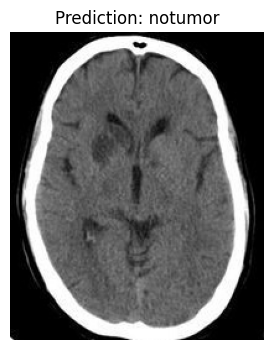

In [14]:
# Cell 15: single-image prediction for the classical sklearn model (no TensorFlow)
from pathlib import Path

# Make this cell runnable even if Cell 10 was not executed.
if "predict_single_image" not in globals():
    def predict_single_image(image_path, model_payload):
        model = model_payload["model"]
        labels = model_payload["class_names"]
        image_size = tuple(model_payload["image_size"])

        feat = extract_features(image_path, image_size=image_size).reshape(1, -1)
        probs = model.predict_proba(feat)[0]
        pred_idx = int(np.argmax(probs))
        return labels[pred_idx], probs

sample_image = TEST_DIR / "notumor" / "Te-no_0010.jpg"

# Use saved payload if available; otherwise build from in-memory trained model.
if "payload" in globals():
    model_payload = payload
elif "MODEL_PATH" in globals() and Path(MODEL_PATH).exists():
    model_payload = joblib.load(MODEL_PATH)
else:
    model_payload = {
        "model": best_model,
        "class_names": class_names,
        "image_size": IMG_SIZE,
    }

pred_label, pred_probs = predict_single_image(sample_image, model_payload)

print("Image:", sample_image)
print("Predicted Label:", pred_label)
print("Probabilities:")
for i, cls in enumerate(model_payload["class_names"]):
    print(f"  {cls:12s}: {pred_probs[i]:.4f}")

img = cv2.imread(str(sample_image))
if img is None:
    raise FileNotFoundError(f"Could not load image: {sample_image}")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.axis("off")
plt.title(f"Prediction: {pred_label}")
plt.show()